In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp
import numpy as np

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer
from probjax.nn import MLP

from models import EDM, Simformer

In [3]:
mlp = MLP([1,2,2,2,2,1], rngs=nnx.Rngs(jax.random.PRNGKey(0)))

mlp_def, mlp_params = nnx.split(mlp)

2024-11-10 13:06:13.413334: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
params_list, tree = jax.tree_util.tree_flatten(mlp_params)
dims_by_id = {i:int(np.prod(x.shape)) for i,x in enumerate(params_list)}

In [5]:
params_flat, unflatten = jax.flatten_util.ravel_pytree(mlp_params)

In [6]:
NUM_PARAMS = len(params_flat)
NUM_PARAMS

25

In [7]:
def generate_data(rng):
    #x = jax.random.uniform(rng, (10,1), minval=-10, maxval=10)
    x = jnp.linspace(-5,5,50).reshape(-1,1)
    params = jax.random.normal(rng, (NUM_PARAMS,))
    params_unravel = unflatten(params)
    mlp = nnx.merge(mlp_def, params_unravel)
    y = mlp(x)
    y += jax.random.normal(rng, y.shape) * 0.001
    data = jnp.concatenate([x, y], axis=-1)
    return params, data.reshape(-1)

-2.494135


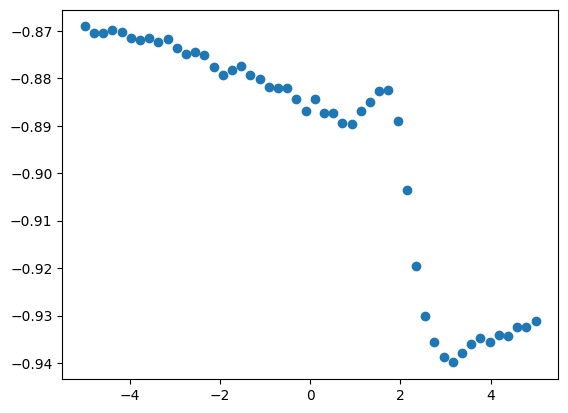

In [8]:
params_model, data = generate_data(jax.random.PRNGKey(0))
print(params_model.sum())
plt.plot(data[::2], data[1::2], 'o')

In [19]:
from functools import partial
from probjax.nn import GaussianFourierEmbedding

class Model(nnx.Module, experimental_pytree=True):

    hidden_dim = 200
    num_layers = 3

    def __init__(self, in_dim, context_dim, rngs):
        self.in_dim = in_dim
        hidden_dim = self.hidden_dim
        num_layers = self.num_layers
        self.context_net = MLP([context_dim,500,200,100], rngs=rngs)
        self.time_net = GaussianFourierEmbedding(1,hidden_dim, rngs=rngs, learnable=True)
        self.in_layer = nnx.Linear(in_dim + 100, hidden_dim, rngs=rngs)
        self.out_layer = nnx.Linear(hidden_dim, in_dim, rngs=rngs)
        self.hidden_layers = [nnx.Linear(hidden_dim,hidden_dim, rngs=rngs) for _ in range(num_layers)]
        self.hidden_layer_norms = [nnx.LayerNorm(hidden_dim, rngs=rngs) for _ in range(num_layers)]
        self.layer_norm1 = nnx.LayerNorm(in_dim+100, rngs=rngs)
        self.layer_norm2 = nnx.LayerNorm(in_dim, rngs=rngs)
        self.rngs = rngs

    def __call__(self, t, x, context):
        context_new = self.context_net(context)
        time = self.time_net(t)
        inp = jnp.concatenate([x, context_new], axis=-1)
        inp = self.layer_norm1(inp)
        h = self.in_layer(inp)
        for i in range(self.num_layers):
            h = self.hidden_layer_norms[i](h)
            h += time
            h = jax.nn.gelu(h)
            h = self.hidden_layers[i](h) + h
           
            
        out = self.out_layer(h)
        out = self.layer_norm2(out)

        skip_connection = t 
        out_connection = 1/jnp.sqrt((0.1 + t))**2

        return out_connection * out + skip_connection * x



In [32]:
thetas, datas = jax.vmap(generate_data)(jax.random.split(jax.random.key(0), 100))
eps = jax.random.normal(jax.random.key(0), shape=thetas.shape)

In [39]:
model = Model(NUM_PARAMS, 100, nnx.Rngs(jax.random.PRNGKey(0)))
params = nnx.state(model, nnx.Param)

from probjax.nn.loss_fn.denoising_score_matching import build_time_dependent_denoising_score_matching_loss

def mean_fn(t, x):
    return x

def std_fn(t, x):
    return jnp.ones_like(x) * t

def weight_fn(t):
    return t


base_loss_fn = build_time_dependent_denoising_score_matching_loss(net, mean_fn, std_fn, weight_fn=weight_fn, control_variate=True)

In [40]:
def loss_fn(params, key, times=None):
    #model = nnx.merge(graphdef, params, state)
    rng, rng_loss, rng_time = jax.random.split(key,3)
    thetas, datas = jax.vmap(generate_data)(jax.random.split(rng, 5000))


    if times is None:
        logt = jax.random.normal(rng_time, shape=(5000, 1)) * 1.2 - 1.2
        t = jnp.exp(logt) + 0.1
    else:
        t = times
    

    # theta_noisy = thetas + jax.random.normal(rng_loss, thetas.shape) * model.std_fn(t)
    # denoised_thetas = model(t, theta_noisy, context=datas)
    # weights = model.weight_fn(t)
    
    #loss = weights[...,None]*(thetas - denoised_thetas)**2

    loss = base_loss_fn(params, t, thetas, datas, rng=rng_loss)


    return loss.mean()

In [41]:
loss_fn(params, jax.random.PRNGKey(5))

Array(1789.247, dtype=float32)

In [42]:
import optax

optimizer = optax.chain(optax.adaptive_grad_clip(10.0), optax.adam(5e-4))
opt_state = optimizer.init(params)
key = jax.random.PRNGKey(1)

@jax.jit
def update(params, opt_state, key):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [43]:

for i in range(50_000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = update(params, opt_state, subkey)
    if i % 1000 == 0:
        print(loss)

14016.169
2005.7798
3540.4185
11218.758
2740.7122
2384.6326
3724.7722
1895.9849
47337.48


KeyboardInterrupt: 

In [44]:
from probjax.utils.odeint import odeint
from probjax.utils.sdeint import sdeint

def naive_diffusion_sampling(key, x_o):
    
    T_end = 20.
    rng_init, rng_solve = jax.random.split(key)
    eps = jax.random.normal(rng_init, (NUM_PARAMS,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.1, T_end, 1000)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((NUM_PARAMS,))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, context=x_o)
        backward_f = (f -g**2*score).reshape(x.shape)
        return backward_f
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((NUM_PARAMS,))
        g = model.diffusion(t, x_) * jnp.ones((NUM_PARAMS,))
        return g.reshape(x.shape)

    return sdeint(rng_solve,drift,diffusion, eps,ts[::-1], noise_type="diagonal")[-1]

In [45]:
theta, x_o = generate_data(jax.random.PRNGKey(2))

In [46]:
samples = jax.vmap(lambda k: naive_diffusion_sampling(k, x_o))(jax.random.split(jax.random.PRNGKey(0), 1000))

AttributeError: 'Model' object has no attribute 'marginal_std'

NameError: name 'samples' is not defined

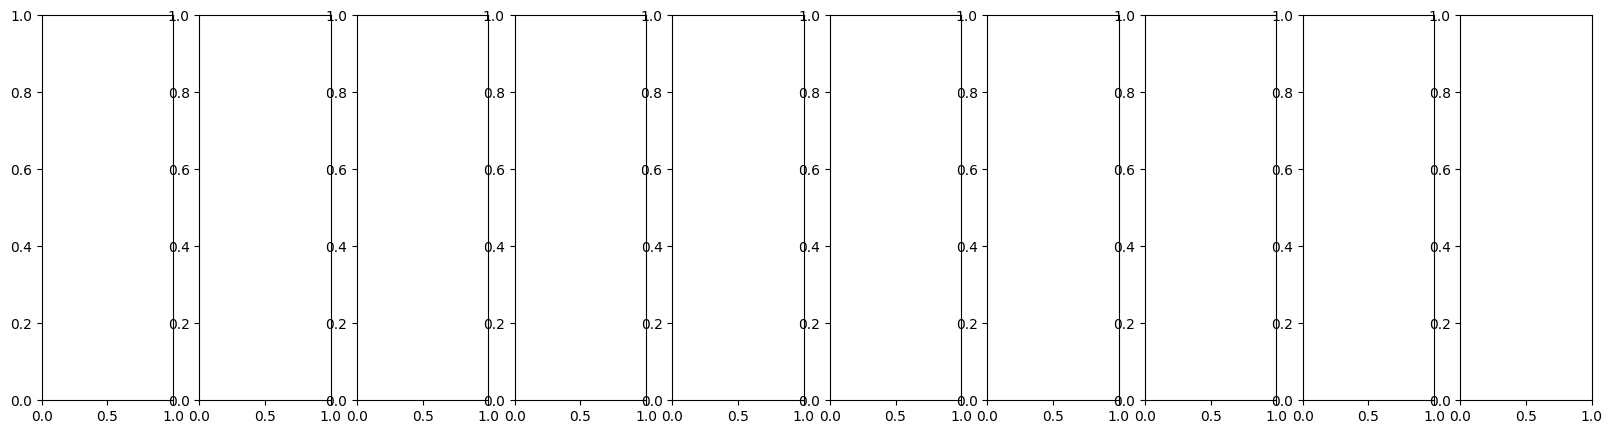

In [47]:
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1,10, figsize=(20,5))
for i, ax in enumerate(axes):
    sns.histplot(samples[:,i], ax=ax)
    ax.axvline(theta[i], color='red')
    ax.set_title(f"theta_{i}")

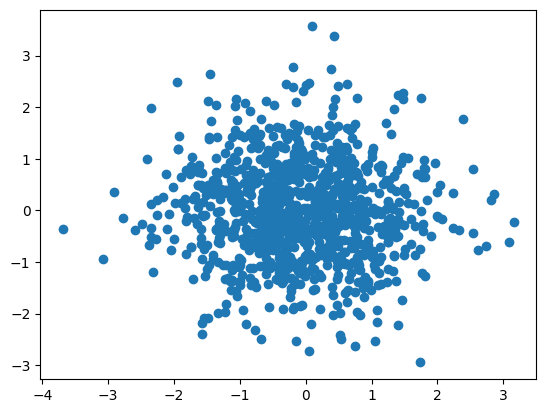

In [ ]:
plt.scatter(samples[:,0], samples[:,1])

In [ ]:
def pred(params, x):
    unflat_params = unflatten(params)
    mlp = nnx.merge(mlp_def, unflat_params)
    return mlp(x)

In [ ]:
ys = jax.vmap(lambda p: pred(p, x_o[::2, None]))(samples)

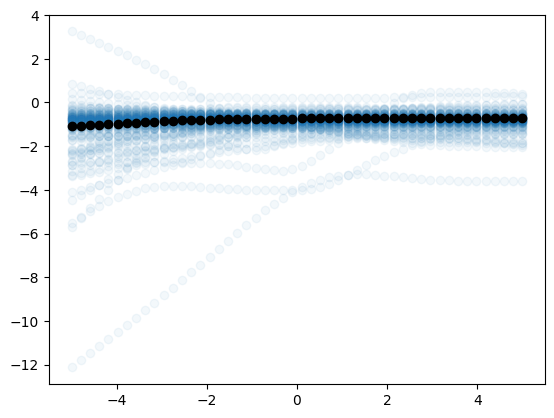

In [ ]:
_ = plt.plot(x_o[::2], ys[:,:,0].T, 'o', color="C0", alpha=0.05)
plt.plot(x_o[::2], x_o[1::2], 'o', color="black")